In [506]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [507]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [508]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [509]:
from utils.cart import make_wcs, to_cart

In [510]:
cmap = 'RdBu_r'

In [511]:
! nvidia-smi

zsh:1: command not found: nvidia-smi


## Fermi data

In [617]:
from scipy.interpolate import interp1d

In [618]:
e_min_interp = np.array(counts_fits[1].data[:])['E_MIN'] / 1e3

In [619]:
from astropy.io import fits

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [620]:
exposure = fits.open("../data/exposure_ultracleanveto_bestpsf_joined.fits")
exposure = exposure[0].data[:, int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = exposure.shape[1] // upsample_factor

In [621]:
exposure_interp = interp1d(e_min_interp, exposure, axis=0)
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) 
exposure_interp = exposure_interp(e_bins).reshape(len(e_bins), -1, upsample_factor, b, upsample_factor).mean((-1, -3))

## Templates

In [622]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [623]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [624]:
np.max(counts_downsampled[~mask_roi])

278

## Zenodo

In [625]:
from astropy.io import fits

In [626]:
import pandas as pd
dif_names = pd.read_csv('/Users/smsharma/Downloads/ZENODO_FILES/NAMING_CONVENTION_OF_DIFFUSE_EMISSION_MODELS.dat', skiprows=1, header=None, delim_whitespace=True)[1].tolist()
dif_names = dif_names[:]

In [627]:
e_bins = np.logspace(np.log10(43.8587), np.log10(714027.0), 38) / 1e3 
e_bins_widths = (e_bins[1:] - e_bins[:-1])
e_bins_centers = (e_bins[1:] + e_bins[:-1]) / 2

In [661]:
# Select energy bins closest to 2 and 20 GeV
e_bin_min_idx = np.argmin(np.abs(e_bins - 2)) #- 1
e_bin_max_idx = np.argmin(np.abs(e_bins - 20)) #- 1

In [662]:
pixel_size_data = 0.25
pixel_size_target = 0.5
extent = 25
upsample_factor = int(pixel_size_target / pixel_size_data)

In [663]:
dif = dif_names[0]

temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

for dif_type in ['bremss', 'pi0', 'ICS']:
    file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
    phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
    n_pix_edge = int((30 - extent) / pixel_size_data)
    n_pix_total = int(2 * extent / pixel_size_data)
    phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
    b = phi.shape[1] // upsample_factor
    phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
    phi *= np.deg2rad(pixel_size_target ** 2)
    phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
    phi /= 1e3
    temp_ary.append(phi[:, ::-1])
    
temp_ary = np.array(temp_ary)
temp_ary.mean((1,2))

array([1.329005  , 1.85003303, 1.00300816, 1.19548247, 0.92873186,
       1.54008749, 2.32903186, 2.53250726])

## Poisson fits

In [664]:
from scipy.optimize import minimize

In [665]:
from scipy.stats import poisson

def likelihood(theta, data, mask=None):
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ik, i -> k", temp_ary[:, ~mask], theta)
    return -poisson.logpmf(data[~mask], temp_sum).mean()

## With ROI mask

In [666]:
from tqdm import tqdm

In [667]:
ll_list = []
opt_list = []
for dif in tqdm(dif_names):
    
    temp_ary = [temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart]

    for dif_type in ['pi0', 'ICS']:
        file = fits.open("/Users/smsharma/Downloads/ZENODO_FILES/GALACTIC_DIFFUSE_EMISSION_MAPS_0p25deg/{}_{}_Map_flux_E_50-814008_MeV_InnerGalaxy_60x60.fits".format(dif_type, dif))
        phi = file[0].data[e_bin_min_idx:e_bin_max_idx + 1] * e_bins_widths[e_bin_min_idx:e_bin_max_idx + 1, None, None] / e_bins_centers[e_bin_min_idx:e_bin_max_idx + 1, None, None] ** 2
        n_pix_edge = int((30 - extent) / pixel_size_data)
        n_pix_total = int(2 * extent / pixel_size_data)
        phi = phi[:, n_pix_edge:n_pix_edge + n_pix_total, n_pix_edge:n_pix_edge + n_pix_total]
        b = phi.shape[1] // upsample_factor
        phi = phi.reshape(e_bin_max_idx - e_bin_min_idx + 1, -1, upsample_factor, b, upsample_factor).sum((-1, -3))
        phi *= np.deg2rad(pixel_size_target ** 2)
        phi = np.sum(exposure_interp[e_bin_min_idx:e_bin_max_idx + 1] * phi, axis=0)
        phi /= 1e3
        temp_ary.append(phi[:, ::-1])

    temp_ary = np.array(temp_ary)

    opt = minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi))
    ll_data = - opt.fun
    
    opt_list.append(opt)
    ll_list.append(ll_data) 

100%|██████████| 80/80 [01:06<00:00,  1.20it/s]


In [701]:
np.array([opt_list[i].x[0] for i in range(len(dif_names))])[np.argmax(np.array(ll_list) * (~mask_roi).sum())]

0.22319544085109705

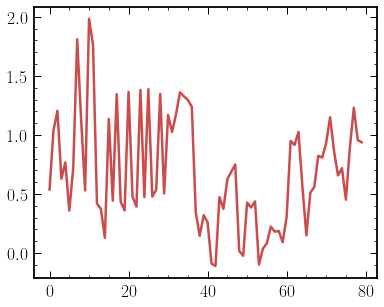

In [702]:
plt.plot(np.array([opt_list[i].x[0] for i in range(len(dif_names))]))

In [703]:
temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_dif_cart])
ll_p6 = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

temp_ary = np.array([temp_gce_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])
ll_mO = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

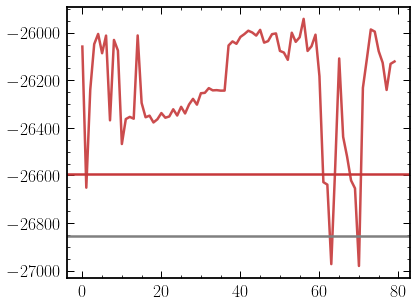

In [706]:
plt.plot(np.array(ll_list) * (~mask_roi).sum())
plt.axhline(ll_p6 * (~mask_roi).sum(), color='grey')
plt.axhline(ll_mO * (~mask_roi).sum())